# HR Attrition Prediction Notebook
Clean version without data leakage and with basic feature engineering.

In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import classification_report, accuracy_score


## Load dataset

In [2]:

df = pd.read_csv("HR_Analytics.csv")
df.head()


,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,10026,0,0,1,1,5,4,0,62506,0,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,10084,1,1,1,5,3,3,0,104437,1,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,10196,1,1,0,5,5,3,0,64955,1,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,10088,1,1,0,1,5,3,0,64991,0,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,10069,0,2,0,5,5,3,0,50825,1,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


## Remove data leakage columns

In [3]:

leak_columns = ['DateofTermination', 'TermReason', 'EmploymentStatus', 'EmpStatusID', 'ManagerName']
df = df.drop(columns=leak_columns)

df.columns


Index(['EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID', 'DeptID',
       'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'Termd',
       'PositionID', 'Position', 'State', 'Sex', 'MaritalDesc', 'CitizenDesc',
       'HispanicLatino', 'RaceDesc', 'DateofHire', 'Department', 'ManagerID',
       'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey',
       'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date',
       'DaysLateLast30', 'Absences'],
      dtype='object')

## Feature Engineering

In [4]:

# Convert dates
df["DateofHire"] = pd.to_datetime(df["DateofHire"])

# Example feature: tenure in years
df["TenureYears"] = (pd.Timestamp.today() - df["DateofHire"]).dt.days / 365

# Drop original date
df = df.drop(columns=["DateofHire"])


## Target variable

In [5]:

target = "Termd"

y = df[target]
X = df.drop(columns=[target])


C:\Users\maxso\AppData\Local\Temp\ipykernel_17856\327307991.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Termd', y='EmpSatisfaction', palette='magma')


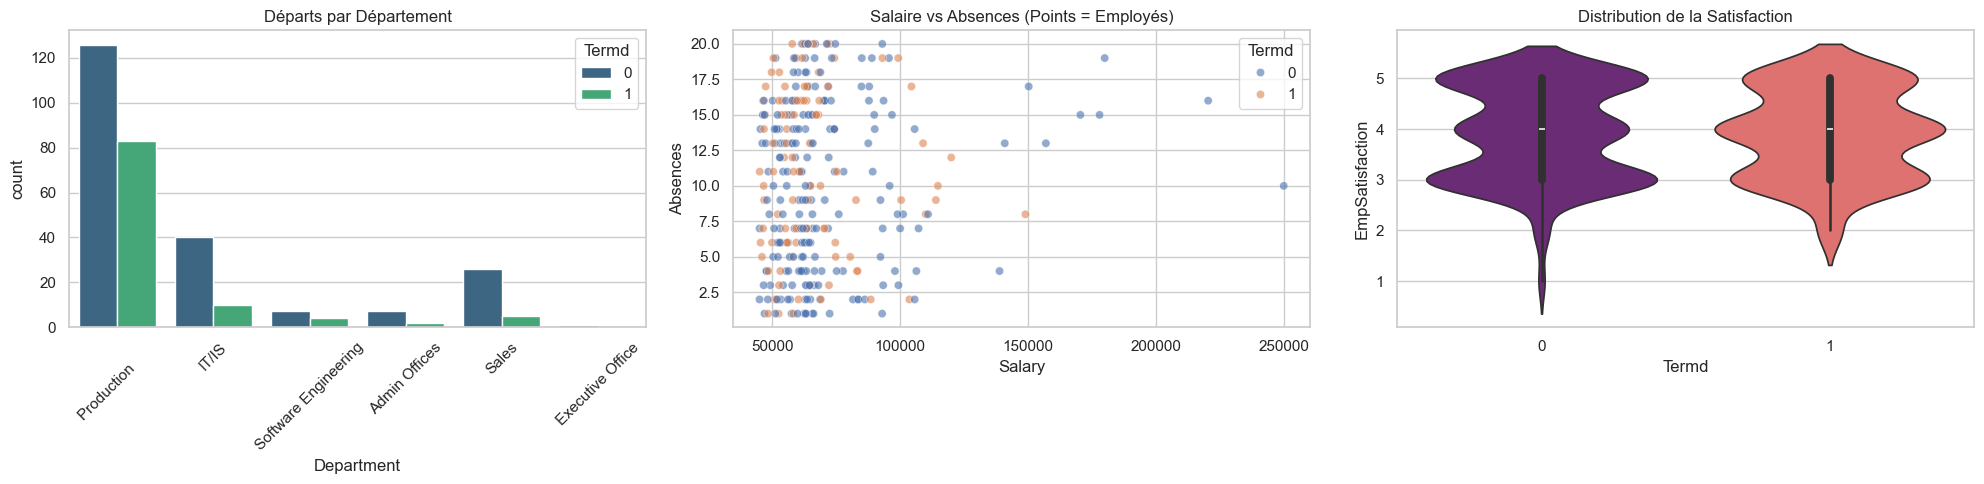

In [6]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=df, x='Department', hue='Termd', palette='viridis')
plt.xticks(rotation=45)
plt.title('Départs par Département')

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='Salary', y='Absences', hue='Termd', alpha=0.6)
plt.title('Salaire vs Absences (Points = Employés)')

plt.subplot(1, 3, 3)
sns.violinplot(data=df, x='Termd', y='EmpSatisfaction', palette='magma')
plt.title('Distribution de la Satisfaction')

plt.tight_layout()
plt.show()

## Keep EmpID only for identification

In [7]:

if "EmpID" in X.columns:
    emp_ids = X["EmpID"]
    X_model = X.drop(columns=["EmpID"])
else:
    X_model = X.copy()


## Detect column types

In [8]:

cat_cols = X_model.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_model.select_dtypes(exclude=["object"]).columns.tolist()

cat_cols, num_cols


(['Position',
  'State',
  'Sex',
  'MaritalDesc',
  'CitizenDesc',
  'HispanicLatino',
  'RaceDesc',
  'Department',
  'RecruitmentSource',
  'PerformanceScore',
  'LastPerformanceReview_Date'],
 ['MarriedID',
  'MaritalStatusID',
  'GenderID',
  'DeptID',
  'PerfScoreID',
  'FromDiversityJobFairID',
  'Salary',
  'PositionID',
  'ManagerID',
  'EngagementSurvey',
  'EmpSatisfaction',
  'SpecialProjectsCount',
  'DaysLateLast30',
  'Absences',
  'TenureYears'])

## Preprocessing pipelines

In [9]:

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocess = ColumnTransformer([
    ("cat", categorical_pipeline, cat_cols),
    ("num", numeric_pipeline, num_cols)
])


## Train/Test split

In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


## Model

In [11]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

comparison_results = []

for name, model in models.items():
    current_pipeline = Pipeline(steps=[
        ('preprocessor', preprocess), 
        ('classifier', model)
    ])
    
    current_pipeline.fit(X_train, y_train)
    
    y_pred = current_pipeline.predict(X_test)
    y_proba = current_pipeline.predict_proba(X_test)[:, 1]
    
    comparison_results.append({
        "Modèle": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    })

df_compare = pd.DataFrame(comparison_results).sort_values(by="F1-Score", ascending=False)
display(df_compare)

c:\Users\maxso\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Modèle,Accuracy,F1-Score,AUC
1,Logistic Regression,0.777778,0.650000,0.800454
2,Gradient Boosting,0.761905,0.615385,0.811791
0,Random Forest,0.777778,0.588235,0.813492


## Full pipeline

In [12]:

best_model = models[df_compare.iloc[0]["Modèle"]]

pipeline = Pipeline([
    ("prep", preprocess),
    ("model", best_model)
])


## Train model

In [13]:

pipeline.fit(X_train, y_train)


c:\Users\maxso\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Position', 'State', 'Sex',
                                                   'MaritalDesc', 'CitizenDesc',
                                                   'HispanicLatino', 'RaceDesc',
                                                   'Department',
                                                   'RecruitmentSource',
                                                   'PerformanceScore',
                                                   'LastPerformanceReview_Date']),
                                                 (...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['MarriedID',
                                                   'MaritalStatusID',
                                                   'GenderID', 'DeptID',
                                                   'PerfScoreID',
                                                   'FromDiversityJobFairID',
                                                   'Salary', 'PositionID',
                                                   'ManagerID',
                                                   'EngagementSurvey',
                                                   'EmpSatisfaction',
                                                   'SpecialProjectsCount',
                                                   'DaysLateLast30', 'Absences',
                                                   'TenureYears'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

## Evaluate model

In [14]:

proba = pipeline.predict_proba(X_test)
pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))


Accuracy: 0.7777777777777778
              precision    recall  f1-score   support

           0       0.82      0.86      0.84        42
           1       0.68      0.62      0.65        21

    accuracy                           0.78        63
   macro avg       0.75      0.74      0.74        63
weighted avg       0.77      0.78      0.77        63



## Attach EmpID to predictions

In [15]:

departure_prob = proba[:,1]

results = df.loc[X_test.index].copy()

results["Prediction"] = pred
results["DepartureProbability"] = departure_prob
results["DepartureProbability"] = results["DepartureProbability"] * 100

results["Real"] = y_test

results[["EmpID","DepartureProbability","Prediction","Real"]].head()


,EmpID,DepartureProbability,Prediction,Real
185,10128,24.168289,0,1
34,10181,59.246913,1,0
310,10271,12.265208,0,0
139,10227,4.260607,0,0
150,10089,69.533032,1,0


In [ ]:
X_full = df.drop(columns=['Termd'])

all_probs = pipeline.predict_proba(X_full)[:, 1]

X_transformed = pipeline.named_steps['prep'].transform(X_full)

if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

features_names = pipeline.named_steps['prep'].get_feature_names_out()

model = pipeline.named_steps['model']

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
elif hasattr(model, "coef_"):
    importances = model.coef_[0]
else:
    raise ValueError("Modèle non compatible")

X_avg = X_transformed.mean(axis=0)

feature_details = []

for i in range(len(X_transformed)):
    diff_to_avg = X_transformed[i] * importances
    top_5_indices = diff_to_avg.argsort()[-5:][::-1]
    
    row_info = []
    for idx in top_5_indices:
        feat_name = features_names[idx]
        
        
        original_col = feat_name.split('__')[-1].split('_')[0]
        
        if original_col in df.columns:
            valeur_reelle = df.iloc[i][original_col]
            row_info.append(f"{feat_name} ({valeur_reelle})")
        else:
            row_info.append(f"{feat_name}")
            
    feature_details.append(row_info)

export_df = df.loc[X_full.index, ['EmpID', 'Termd']].copy()
export_df['Risque_%'] = (all_probs * 100).round(2)

cols_names = ['Facteur_1', 'Facteur_2', 'Facteur_3', 'Facteur_4', 'Facteur_5']
features_df = pd.DataFrame(feature_details, columns=cols_names, index=export_df.index)

final_export = pd.concat([export_df, features_df], axis=1)

final_export = final_export[final_export['Termd'] == 0].drop(columns=['Termd'])

final_export.sort_values(by='Risque_%', ascending=False, inplace=True)

final_export.to_excel("Audit_Attrition_Complet.xlsx", index=False)

print("✅ Excel généré avec succès")
display(final_export.head(10))

✅ Excel généré avec succès


,EmpID,Risque_%,Facteur_1,Facteur_2,Facteur_3,Facteur_4,Facteur_5
190,10288,92.50,num__TenureYears (14.093150684931507),num__EmpSatisfaction (3),num__DaysLateLast30 (4),cat__Department_IT/IS (IT/IS),num__EngagementSurvey (2.39)
97,10080,90.22,num__TenureYears (17.205479452054796),num__EmpSatisfaction (3),num__EngagementSurvey (5.0),num__ManagerID (9.0),cat__RaceDesc_White (White)
23,10294,82.27,num__TenureYears (14.961643835616439),num__ManagerID (22.0),num__EmpSatisfaction (3),cat__Position_Production Technician II (Produc...,num__DaysLateLast30 (2)
54,10282,81.72,num__TenureYears (15.668493150684931),num__EmpSatisfaction (2),num__DaysLateLast30 (3),num__EngagementSurvey (4.13),cat__MaritalDesc_Divorced (Divorced)
248,10233,78.32,num__TenureYears (15.556164383561644),num__ManagerID (18.0),num__EmpSatisfaction (3),num__EngagementSurvey (4.1),cat__Position_Production Technician II (Produc...
3,10088,75.78,num__TenureYears (18.202739726027396),num__EmpSatisfaction (5),num__ManagerID (16.0),num__EngagementSurvey (4.84),cat__RaceDesc_White (White)
266,10278,73.23,num__TenureYears (15.191780821917808),num__EmpSatisfaction (4),num__ManagerID (20.0),cat__RecruitmentSource_Google Search (Google S...,num__EngagementSurvey (4.1)
122,10125,71.59,num__TenureYears (14.30958904109589),num__EmpSatisfaction (4),num__ManagerID (22.0),cat__RecruitmentSource_Google Search (Google S...,num__EngagementSurvey (4.2)
29,10238,70.26,num__TenureYears (17.397260273972602),num__EmpSatisfaction (2),num__EngagementSurvey (4.5),num__FromDiversityJobFairID (1),cat__RecruitmentSource_Diversity Job Fair (Div...
150,10089,69.53,num__TenureYears (13.715068493150685),num__EmpSatisfaction (3),num__EngagementSurvey (4.83),num__ManagerID (9.0),cat__RaceDesc_White (White)
